In [ ]:
import sys, glob, os
import cv2
import matplotlib.pyplot as plt
import os
sys.path.append("d:/USDA-NIFA/Code")
os.chdir("d:/USDA-NIFA/Code")
os.getcwd()

'c:\\Users\\vince\\Desktop\\USDA-NIFA\\Code'

In [2]:
from micasense.image import Image
from micasense.panel import Panel

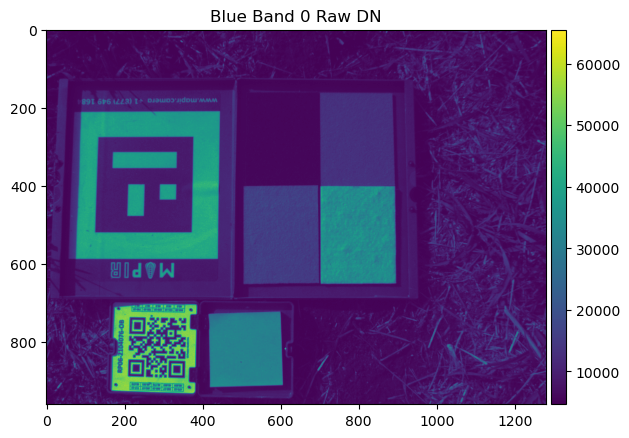

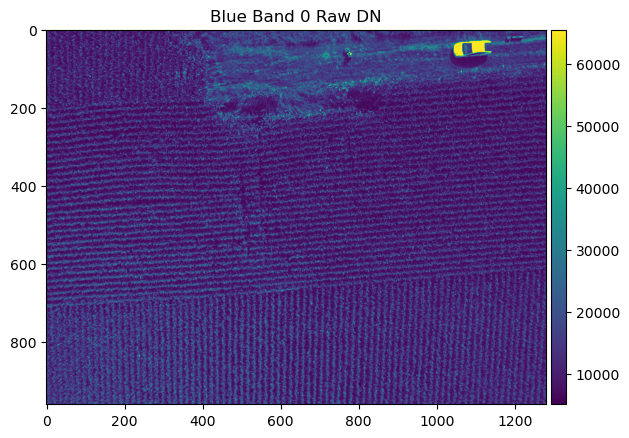

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Blue Band 0 Raw DN'}>)

In [3]:
imagePath = "./B1"
panelimages_list = glob.glob(os.path.join(imagePath,"Panel", 'IMG_0000_*.tif'))
flightimages_list  = [img for img in glob.glob(os.path.join(imagePath, "Images", 'IMG_00*_*.tif')) if 'IMG_0000_' not in img]

samplePanelImage = Image(panelimages_list[0])
sampleFlightImage = Image(flightimages_list[0])

samplePanelImage.plot_raw()
sampleFlightImage.plot_raw()

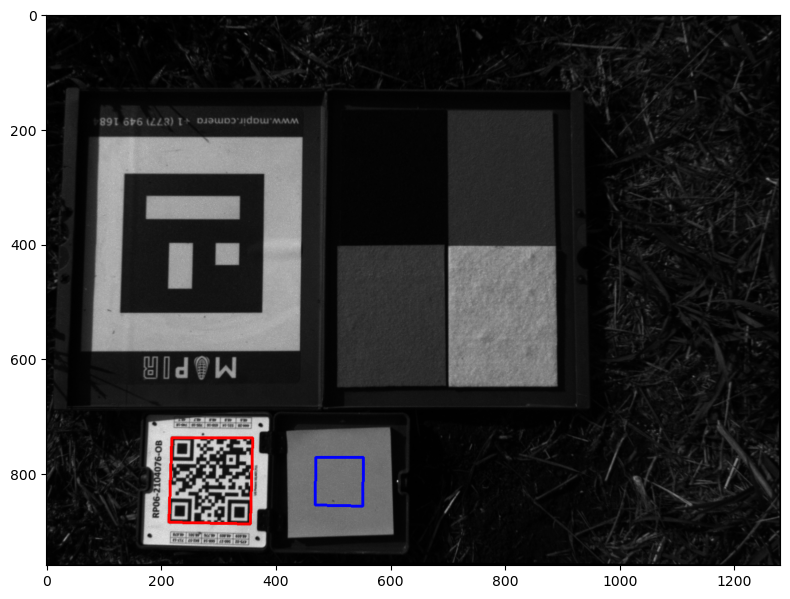

In [4]:
panel = Panel(samplePanelImage)
if not panel.panel_detected():
    raise IOError("Panel Not Detected! Check your installation of pyzbar")
else:
    panel.plot(figsize=(8,8))

In [5]:
panel.panel_version

6

In [6]:
print('{0} {1} firmware version: {2}'.format(sampleFlightImage.meta.camera_make(),
                                             sampleFlightImage.meta.camera_model(), 
                                             sampleFlightImage.meta.firmware_version()))
print('Exposure Time: {0} seconds'.format(sampleFlightImage.meta.exposure()))
print('Image Gain: {0}'.format(sampleFlightImage.meta.gain()))
print('Size: {0}x{1} pixels'.format(sampleFlightImage.meta.image_size()[0],
                                    sampleFlightImage.meta.image_size()[1]))
print('Band Name: {0}'.format(sampleFlightImage.meta.band_name()))
print('Center Wavelength: {0} nm'.format(sampleFlightImage.meta.center_wavelength()))
print('Bandwidth: {0} nm'.format(sampleFlightImage.meta.bandwidth()))
print('Capture ID: {0}'.format(sampleFlightImage.meta.capture_id()))
print('Flight ID: {0}'.format(sampleFlightImage.meta.flight_id()))

MicaSense RedEdge-M firmware version: v7.5.0
Exposure Time: 0.0012375 seconds
Image Gain: 2.0
Size: 1280x960 pixels
Band Name: Blue
Center Wavelength: 475 nm
Bandwidth: 32 nm
Capture ID: C66J2yEVbQEqd1DqOfxX
Flight ID: Rn3kNXcxNIueoCnLWQSj


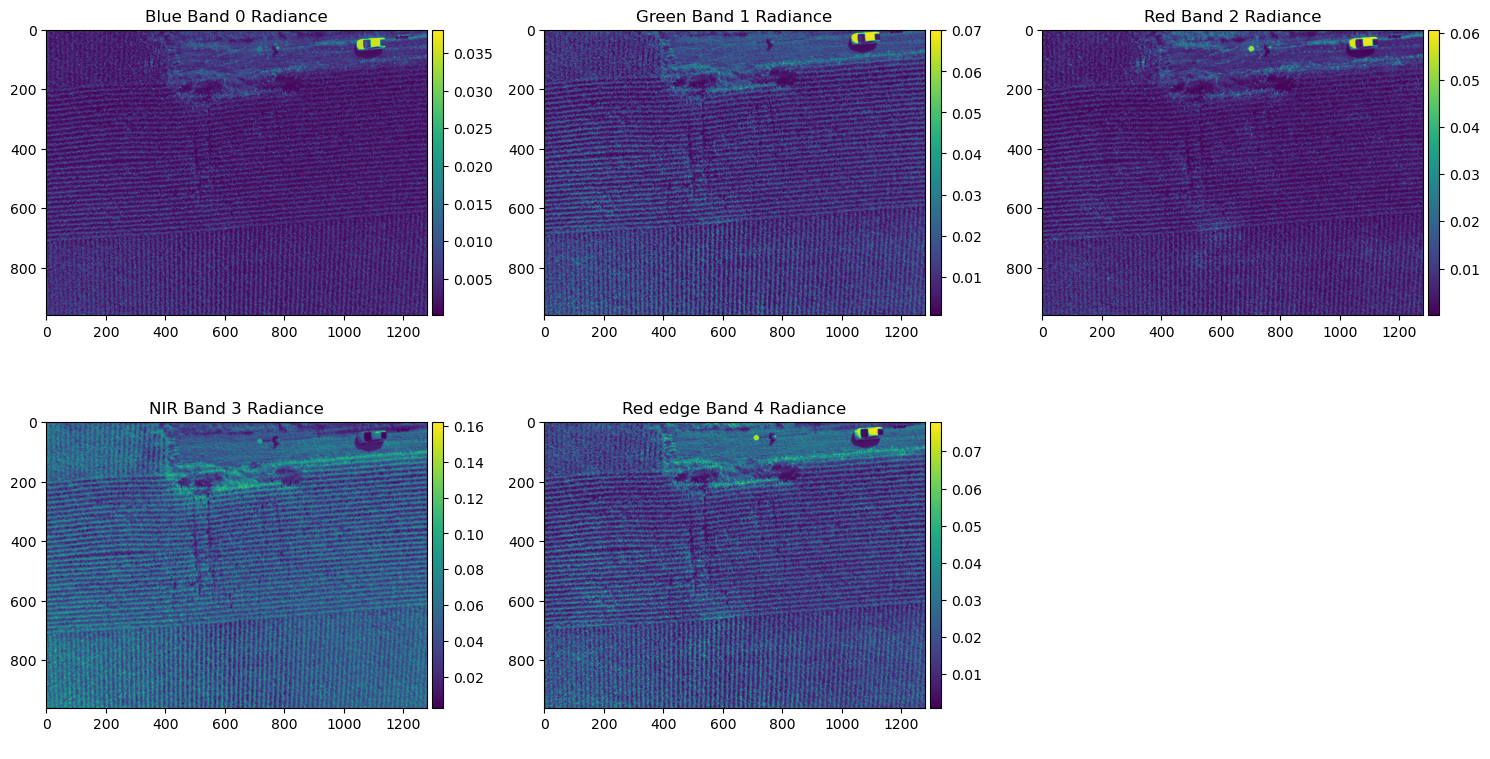

In [7]:
import micasense.capture as capture
image_names = glob.glob(os.path.join(imagePath, "Images", 'IMG_0007_*.tif'))
cap = capture.Capture.from_filelist(image_names)
cap.plot_radiance()